# Bank marketing dataset — data processing

End-to-end loading, quality checks, cleaning, and feature preparation for `data/bank-full.csv` (UCI Bank Marketing).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 25)

DATA_PATH = Path("data/bank-full.csv")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load raw data

In [2]:
assert DATA_PATH.exists(), f"Missing file: {DATA_PATH.resolve()}"

df = pd.read_csv(DATA_PATH, sep=";")
print("Shape:", df.shape)
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 2. Schema, types, and missing values

In [3]:
display(df.info())

na_counts = df.isna().sum()
na_counts[na_counts > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


None

Series([], dtype: int64)

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols and c != "y"]

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

df.describe().T

Numeric: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


### Sentinel values and implicit missingness

In this dataset, `pdays == -1` means the client was not contacted in the previous campaign (not a real day count). We record that explicitly below.

In [5]:
unknown_like = df[categorical_cols].eq("unknown").sum().sort_values(ascending=False)
unknown_like[unknown_like > 0]

poutcome     36959
contact      13020
education     1857
job            288
dtype: int64

## 3. Duplicates and consistency

In [6]:
dup_mask = df.duplicated()
n_dup = dup_mask.sum()
print(f"Duplicate rows (all columns): {n_dup}")

key_cols = [c for c in df.columns if c not in {"duration", "campaign"}]  # exclude call outcomes if modeling leakage
dup_key = df.duplicated(subset=key_cols)
print(f"Duplicates on subset (excluding duration, campaign): {dup_key.sum()}")

df_clean = df.loc[~dup_mask].copy()
print("After dropping exact duplicates:", df_clean.shape)

Duplicate rows (all columns): 0
Duplicates on subset (excluding duration, campaign): 53
After dropping exact duplicates: (45211, 17)


## 4. Target variable and class balance

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

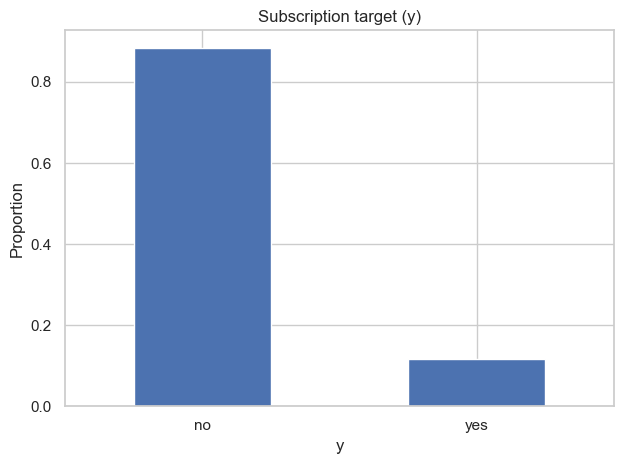

In [7]:
target = "y"
vc = df_clean[target].value_counts(normalize=True)
display(vc)
vc.plot(kind="bar", title="Subscription target (y)", rot=0)
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

## 5. Outliers and distributions (numeric)

balance: IQR outliers = 4729 (bounds [-1962.00, 3462.00])
duration: IQR outliers = 3235 (bounds [-221.00, 643.00])
campaign: IQR outliers = 3064 (bounds [-2.00, 6.00])
age: IQR outliers = 487 (bounds [10.50, 70.50])


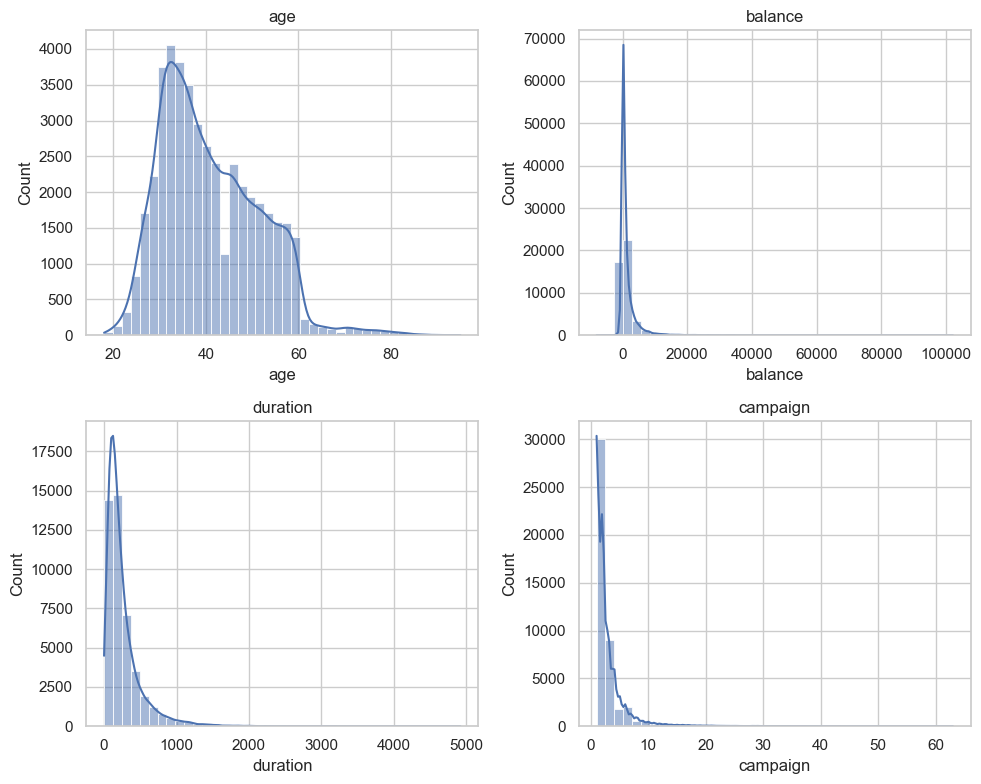

In [8]:
def iqr_bounds(s: pd.Series, k: float = 1.5) -> tuple[float, float]:
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


for col in ["balance", "duration", "campaign", "age"]:
    lo, hi = iqr_bounds(df_clean[col])
    out = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    print(f"{col}: IQR outliers = {out} (bounds [{lo:.2f}, {hi:.2f}])")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), ["age", "balance", "duration", "campaign"]):
    sns.histplot(df_clean[col], bins=40, kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 6. Cleaned frame with engineered features

In [9]:
processed = df_clean.copy()

processed["y_binary"] = (processed["y"] == "yes").astype(np.int8)

processed["pdays_was_contacted"] = (processed["pdays"] != -1).astype(np.int8)
processed["pdays_since_prev"] = processed["pdays"].where(processed["pdays"] != -1, np.nan)

month_order = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec",
]
processed["month"] = pd.Categorical(processed["month"], categories=month_order, ordered=True)
processed["month_ord"] = processed["month"].cat.codes.replace(-1, np.nan).astype("Int64")

education_order = ["primary", "secondary", "tertiary", "unknown"]
processed["education"] = pd.Categorical(
    processed["education"], categories=education_order, ordered=True
)
processed["education_ord"] = processed["education"].cat.codes.replace(-1, np.nan).astype("Int64")

for c in ["default", "housing", "loan"]:
    processed[f"{c}_binary"] = (processed[c] == "yes").astype(np.int8)

# Signed log handles negative balances (common in this dataset).
processed["balance_signed_log"] = np.sign(processed["balance"]) * np.log1p(
    np.abs(processed["balance"])
)

processed.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,...,previous,poutcome,y,y_binary,pdays_was_contacted,pdays_since_prev,month_ord,education_ord,default_binary,housing_binary,loan_binary,balance_signed_log
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,...,0,unknown,no,0,0,NaN,4,2,0,1,0,7.670429
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,...,0,unknown,no,0,0,NaN,4,1,0,1,0,3.401197
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,...,0,unknown,no,0,0,NaN,4,1,0,1,1,1.098612
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,...,0,unknown,no,0,0,NaN,4,3,0,1,0,7.317876
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,...,0,unknown,no,0,0,NaN,4,3,0,0,0,0.693147


### Correlation among numeric / engineered columns

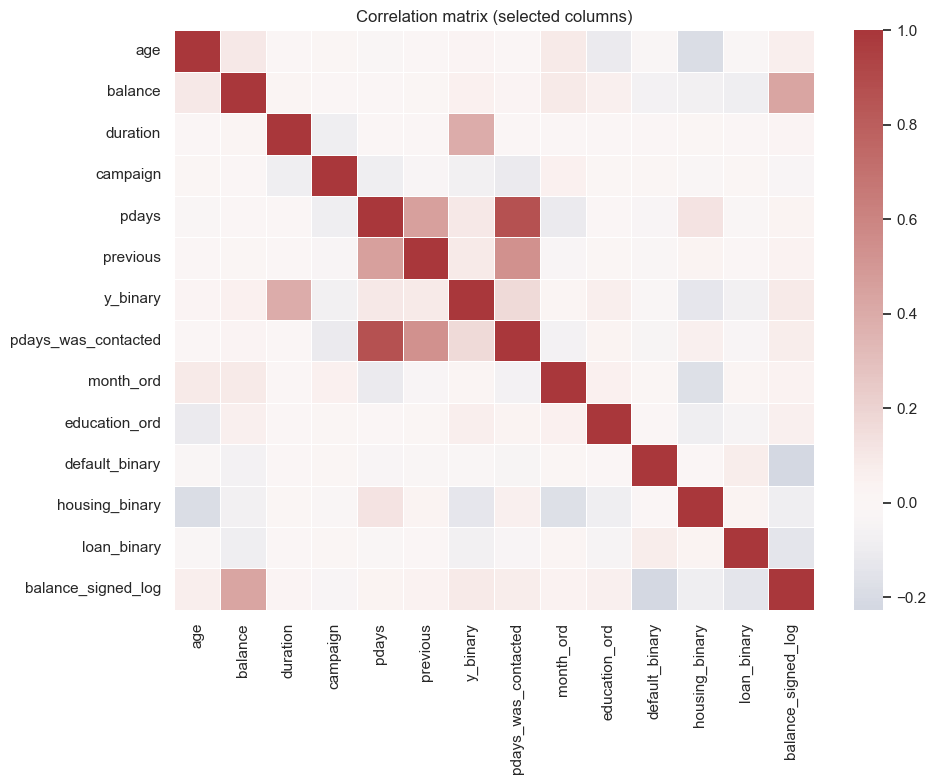

In [10]:
corr_cols = [
    "age",
    "balance",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "y_binary",
    "pdays_was_contacted",
    "month_ord",
    "education_ord",
    "default_binary",
    "housing_binary",
    "loan_binary",
    "balance_signed_log",
]
corr = processed[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="vlag", center=0, linewidths=0.5)
plt.title("Correlation matrix (selected columns)")
plt.tight_layout()
plt.show()

## save processed table

In [11]:
out_path = Path("data/bank-full-processed.parquet")
try:
    processed.to_parquet(out_path, index=False)
    print(f"Saved: {out_path.resolve()}")
except ImportError:
    csv_fallback = Path("data/bank-full-processed.csv")
    processed.to_csv(csv_fallback, index=False)
    print(f"pyarrow/fastparquet not installed; saved CSV: {csv_fallback.resolve()}")

Saved: /Users/kofibadu/Desktop/Spring_ML/IDS_705_final_project/data/bank-full-processed.parquet
